<a href="https://colab.research.google.com/github/sowonjeong/slm-2-llm/blob/main/the-federalist-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/colab-github/txt-analysis

/content/drive/MyDrive/colab-github/txt-analysis


# the Federalist Paper data from [the Project Gutenberg](https://www.gutenberg.org/)

https://pypi.org/project/Gutenberg/

In [ ]:
import pandas as pd
import numpy as np
import os
import nltk, re, pprint
from nltk import word_tokenize
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 0. Prepare Data

* Import the Data formatted through R
* Preprocess the dataset: define the stop words, tokenize the text

In [ ]:
import json
with open("federalist.json") as f:
    federalist_dict = json.load(f)

In [ ]:
# federalist_dict[0]['paper']

authorship source: https://guides.loc.gov/federalist-papers/full-text

In [ ]:
import pandas as pd

# Initialize an empty list to store the flattened data
flattened_data = []

# Iterate over each dictionary in the list
for item in federalist_dict:
    # Extract metadata and content
    meta = item['meta'][0]  # Assuming there's only one meta per item
    paper = item['paper'][0] if item['paper'] else ''  # Assuming content is a list

    # Flatten the data
    flattened_data.append({
        'meta_number': meta.get('number', ''),
        'meta_author': meta.get('author', ''),
        'meta_title': meta.get('title', ''),
        'meta_journal': meta.get('journal', ''),
        'meta_body': paper
    })

# Create a DataFrame
df = pd.DataFrame(flattened_data)
federalist_df = df.drop(df.index[69])

In [ ]:
federalist_df['meta_body'][0]

'To the People of the State of New York:\n\nAfter an unequivocal experience of the inefficacy of the subsisting federal government, you are called upon to deliberate on a new Constitution for the United States of America. The subject speaks its own importance; comprehending in its consequences nothing less than the existence of the UNION, the safety and welfare of the parts of which it is composed, the fate of an empire in many respects the most interesting in the world. It has been frequently remarked that it seems to have been reserved to the people of this country, by their conduct and example, to decide the important question, whether societies of men are really capable or not of establishing good government from reflection and choice, or whether they are forever destined to depend for their political constitutions on accident and force. If there be any truth in the remark, the crisis at which we are arrived may with propriety be regarded as the era in which that decision is to be 

In [ ]:
import numpy as np
federalist_df.index = np.arange(85)

In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize
federalist_df['meta_sentence'] = federalist_df['meta_body'].apply(sent_tokenize)
federalist_df['meta_words'] = federalist_df['meta_sentence'].apply(lambda sentences: [word_tokenize(sentence) for sentence in sentences])


In [ ]:
import warnings
import pandas as pd
from nltk.tokenize import word_tokenize

# Suppress specific FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Assuming federalist_df is defined and has the required columns

# Create a list to store sentence-level data
sentence_data = []

# Iterate over each row in the original DataFrame
for index, row in federalist_df.iterrows():
    for i, sentence in enumerate(row['meta_sentence']):
        # Count the number of words in the sentence
        word_count = len(word_tokenize(sentence))

        # Append the data to the sentence_data list
        sentence_data.append({'meta_number': row['meta_number'],
                              'meta_author': row['meta_author'],
                              'meta_sentence_number': i + 1,
                              'meta_sentence': sentence,
                              'meta_num_of_words': word_count})

# Convert the list of dictionaries to a DataFrame
sentence_df = pd.DataFrame(sentence_data)

sentence_df


,meta_number,meta_author,meta_sentence_number,meta_sentence,meta_num_of_words
0,1,HAMILTON,1,To the People of the State of New York:\n\nAft...,40
1,1,HAMILTON,2,The subject speaks its own importance; compreh...,48
2,1,HAMILTON,3,It has been frequently remarked that it seems ...,66
3,1,HAMILTON,4,"If there be any truth in the remark, the crisi...",60
4,1,HAMILTON,5,This idea will add the inducements of philanth...,29
...,...,...,...,...,...
5733,85,HAMILTON,74,I dread the more the consequences of new attem...,36
5734,85,HAMILTON,75,PUBLIUS.,2
5735,85,HAMILTON,76,[1] Entitled “An Address to the People of the ...,43
5736,85,HAMILTON,77,"[3] Hume’s _Essays_, vol.",10


In [ ]:
# Group by 'meta_author' and calculate the mean of 'number_of_words' for each author
sentence_df.groupby('meta_author')['meta_num_of_words'].mean()

meta_author
HAMILTON                37.525829
HAMILTON AND MADISON    30.331776
HAMILTON OR MADISON     34.101911
JAY                     43.333333
MADISON                 37.011925
Name: meta_num_of_words, dtype: float64

In [ ]:
sentence_df.groupby(['meta_author', 'meta_number']).size()#.group_by(level='meta_author').mean()

meta_author  meta_number
HAMILTON     1              49
             6              74
             7              85
             8              73
             9              64
                            ..
MADISON      44             76
             45             57
             46             77
             47             87
             48             57
Length: 85, dtype: int64

In [ ]:
# Load the regular expression library
import re
word_df = sentence_df.copy()
# Remove punctuation
word_df['meta_word'] = \
word_df['meta_sentence'].map(lambda x: re.sub('[,\.!?]', '', x))
# Convert the titles to lowercase
word_df['meta_word'] = \
word_df['meta_word'].map(lambda x: x.lower())
word_df['meta_word'].head()

0    to the people of the state of new york:\n\naft...
1    the subject speaks its own importance; compreh...
2    it has been frequently remarked that it seems ...
3    if there be any truth in the remark the crisis...
4    this idea will add the inducements of philanth...
Name: meta_word, dtype: object

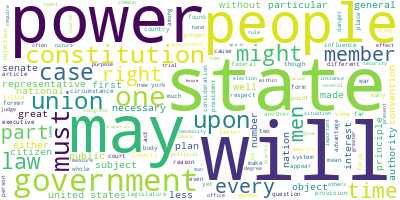

In [ ]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ','.join(list(word_df['meta_word'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=5, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

In [ ]:
import gensim
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

data = word_df['meta_word'].values.tolist()
#list(sent_to_words(data))

# TOPIC Model Setup

In [ ]:
import os
import pandas as pd
from time import time
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

TI_IDF Score
$$ w_{ij} = TF_{ij} * log(\frac{M}{df_{j}})$$
* `$TF_{ij}$` is the number of times the term `$T_j$` in the document $D_i$.
* `$df_j$` is the number of documents containing the term $T_j$.
* `M` is the number of document.
* `N` is vocabulary size.

A term occurs frequently in a particular document and rarely across the entire corpus has a higher IDF score.

In [ ]:
# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')
# Vectorize document using TF-IDF
tfidf_vectorizer = TfidfVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        smooth_idf=True)
                        #tokenizer = tokenizer.tokenize)
# Fit and Transform the documents
tfidf = tfidf_vectorizer.fit_transform(federalist_df['meta_body'])

In [ ]:
# Use tf (raw term count) features for LDA.
print("Extracting tf features for LDA...")
tf_vectorizer = CountVectorizer(
    lowercase = True,
    # max_df=0.95, min_df=2,
    max_features=2000,
    stop_words="english",
    ngram_range = (1,1)
)
tf = tf_vectorizer.fit_transform(federalist_df['meta_body'])

Extracting tf features for LDA...


In [ ]:
def print_top_words(out_components, terms, topn = 5):
  # Print the topics with their terms
  for index, component in enumerate(out_components):
      zipped = zip(terms, component)
      top_terms_key=sorted(zipped, key = lambda t: t[1], reverse=True)[:topn]
      top_terms_list=list(dict(top_terms_key).keys())
      print("Topic "+str(index)+": ",top_terms_list)

In [ ]:
def plot_top_words(components, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(components):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

## LDA(Latent Dirichlet Allocation)

In [ ]:
# Define the number of topics or components
num_components=10
# Create LDA object
lda=LatentDirichletAllocation(n_components=num_components)
# Fit and Transform SVD model on data
lda_matrix = lda.fit_transform(tf)
# Get Components
lda_components=lda.components_

## Nonnegative Matrix Factorization(NMF)

Given $A$, a nonnegative matrix, we want to decompose this into $A = WV$, where both $W$ and $V$ are nonnegative matrices.

* $A \in \mathbb{R}^{M \times N}$
* $W \in \mathbb{R}^{M \times T}$ T is the number of topics
* $N \in \mathbb{R}^{T \times N}$

In [ ]:
input = tfidf.todense()

In [ ]:
input.shape

(85, 8382)

In [ ]:
from sklearn.decomposition import NMF
NMF_mod = NMF(n_components = 10, random_state = 1)
W = NMF_mod.fit_transform(np.asarray(input))
H = NMF_mod.components_

In [ ]:
np.savetxt('NMF_H.csv', H, delimiter=',', fmt='%.5f')
np.savetxt('NMF_W.csv', W, delimiter = ',', fmt='%.5f')

## SVD(Latent Semantic Analysis)

In [ ]:
# Naive way to graph a cluster is just reduce the dimensions to 2 with svd
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=10)
#svd.fit(X_set[ftn_words_columns])
svd_mod = svd.fit(np.asarray(input))
svd_comp = svd.components_ # the right singular vectors(column space) word-topic


# Compare the results

In [ ]:
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
feature_names_tf = tf_vectorizer.get_feature_names_out()

In [ ]:
print_top_words(lda_components, feature_names_tf)

Topic 0:  ['government', 'people', 'state', 'states', 'federal']
Topic 1:  ['state', 'power', 'courts', 'court', 'cases']
Topic 2:  ['president', 'senate', 'appointments', 'body', 'people']
Topic 3:  ['revenue', 'state', 'duties', 'taxes', 'taxation']
Topic 4:  ['states', 'state', 'government', 'constitution', 'convention']
Topic 5:  ['government', 'states', 'union', 'power', 'national']
Topic 6:  ['empire', 'members', 'emperor', 'diet', 'confederacy']
Topic 7:  ['power', 'president', 'executive', 'body', 'magistrate']
Topic 8:  ['executive', 'legislative', 'constitution', 'department', 'power']
Topic 9:  ['states', 'power', 'state', 'constitution', 'shall']


In [ ]:
print_top_words(H, feature_names_tfidf)

Topic 0:  ['government', 'state', 'federal', 'people', 'governments']
Topic 1:  ['executive', 'legislative', 'department', 'departments', 'judiciary']
Topic 2:  ['courts', 'court', 'jury', 'jurisdiction', 'cases']
Topic 3:  ['representatives', 'elections', 'state', 'people', 'states']
Topic 4:  ['senate', 'president', 'body', 'treaties', 'nomination']
Topic 5:  ['nations', 'confederacies', 'war', 'navigation', 'states']
Topic 6:  ['armies', 'military', 'establishments', 'militia', 'standing']
Topic 7:  ['states', 'power', 'powers', 'state', 'constitution']
Topic 8:  ['taxation', 'revenue', 'taxes', 'state', 'duties']
Topic 9:  ['government', 'people', 'convention', 'majority', 'men']


In [ ]:
print_top_words(svd_comp,feature_names_tfidf)

Topic 0:  ['government', 'states', 'state', 'people', 'power']
Topic 1:  ['executive', 'senate', 'president', 'legislative', 'body']
Topic 2:  ['courts', 'court', 'jurisdiction', 'jury', 'supreme']
Topic 3:  ['representatives', 'elections', 'state', 'federal', 'states']
Topic 4:  ['legislative', 'departments', 'department', 'executive', 'judiciary']
Topic 5:  ['courts', 'court', 'jury', 'causes', 'trial']
Topic 6:  ['armies', 'elections', 'militia', 'military', 'standing']
Topic 7:  ['states', 'confederation', 'treaties', 'foreign', 'coin']
Topic 8:  ['executive', 'legislative', 'knowledge', 'commerce', 'revenue']
Topic 9:  ['convention', 'confederation', 'congress', 'rights', 'constitution']


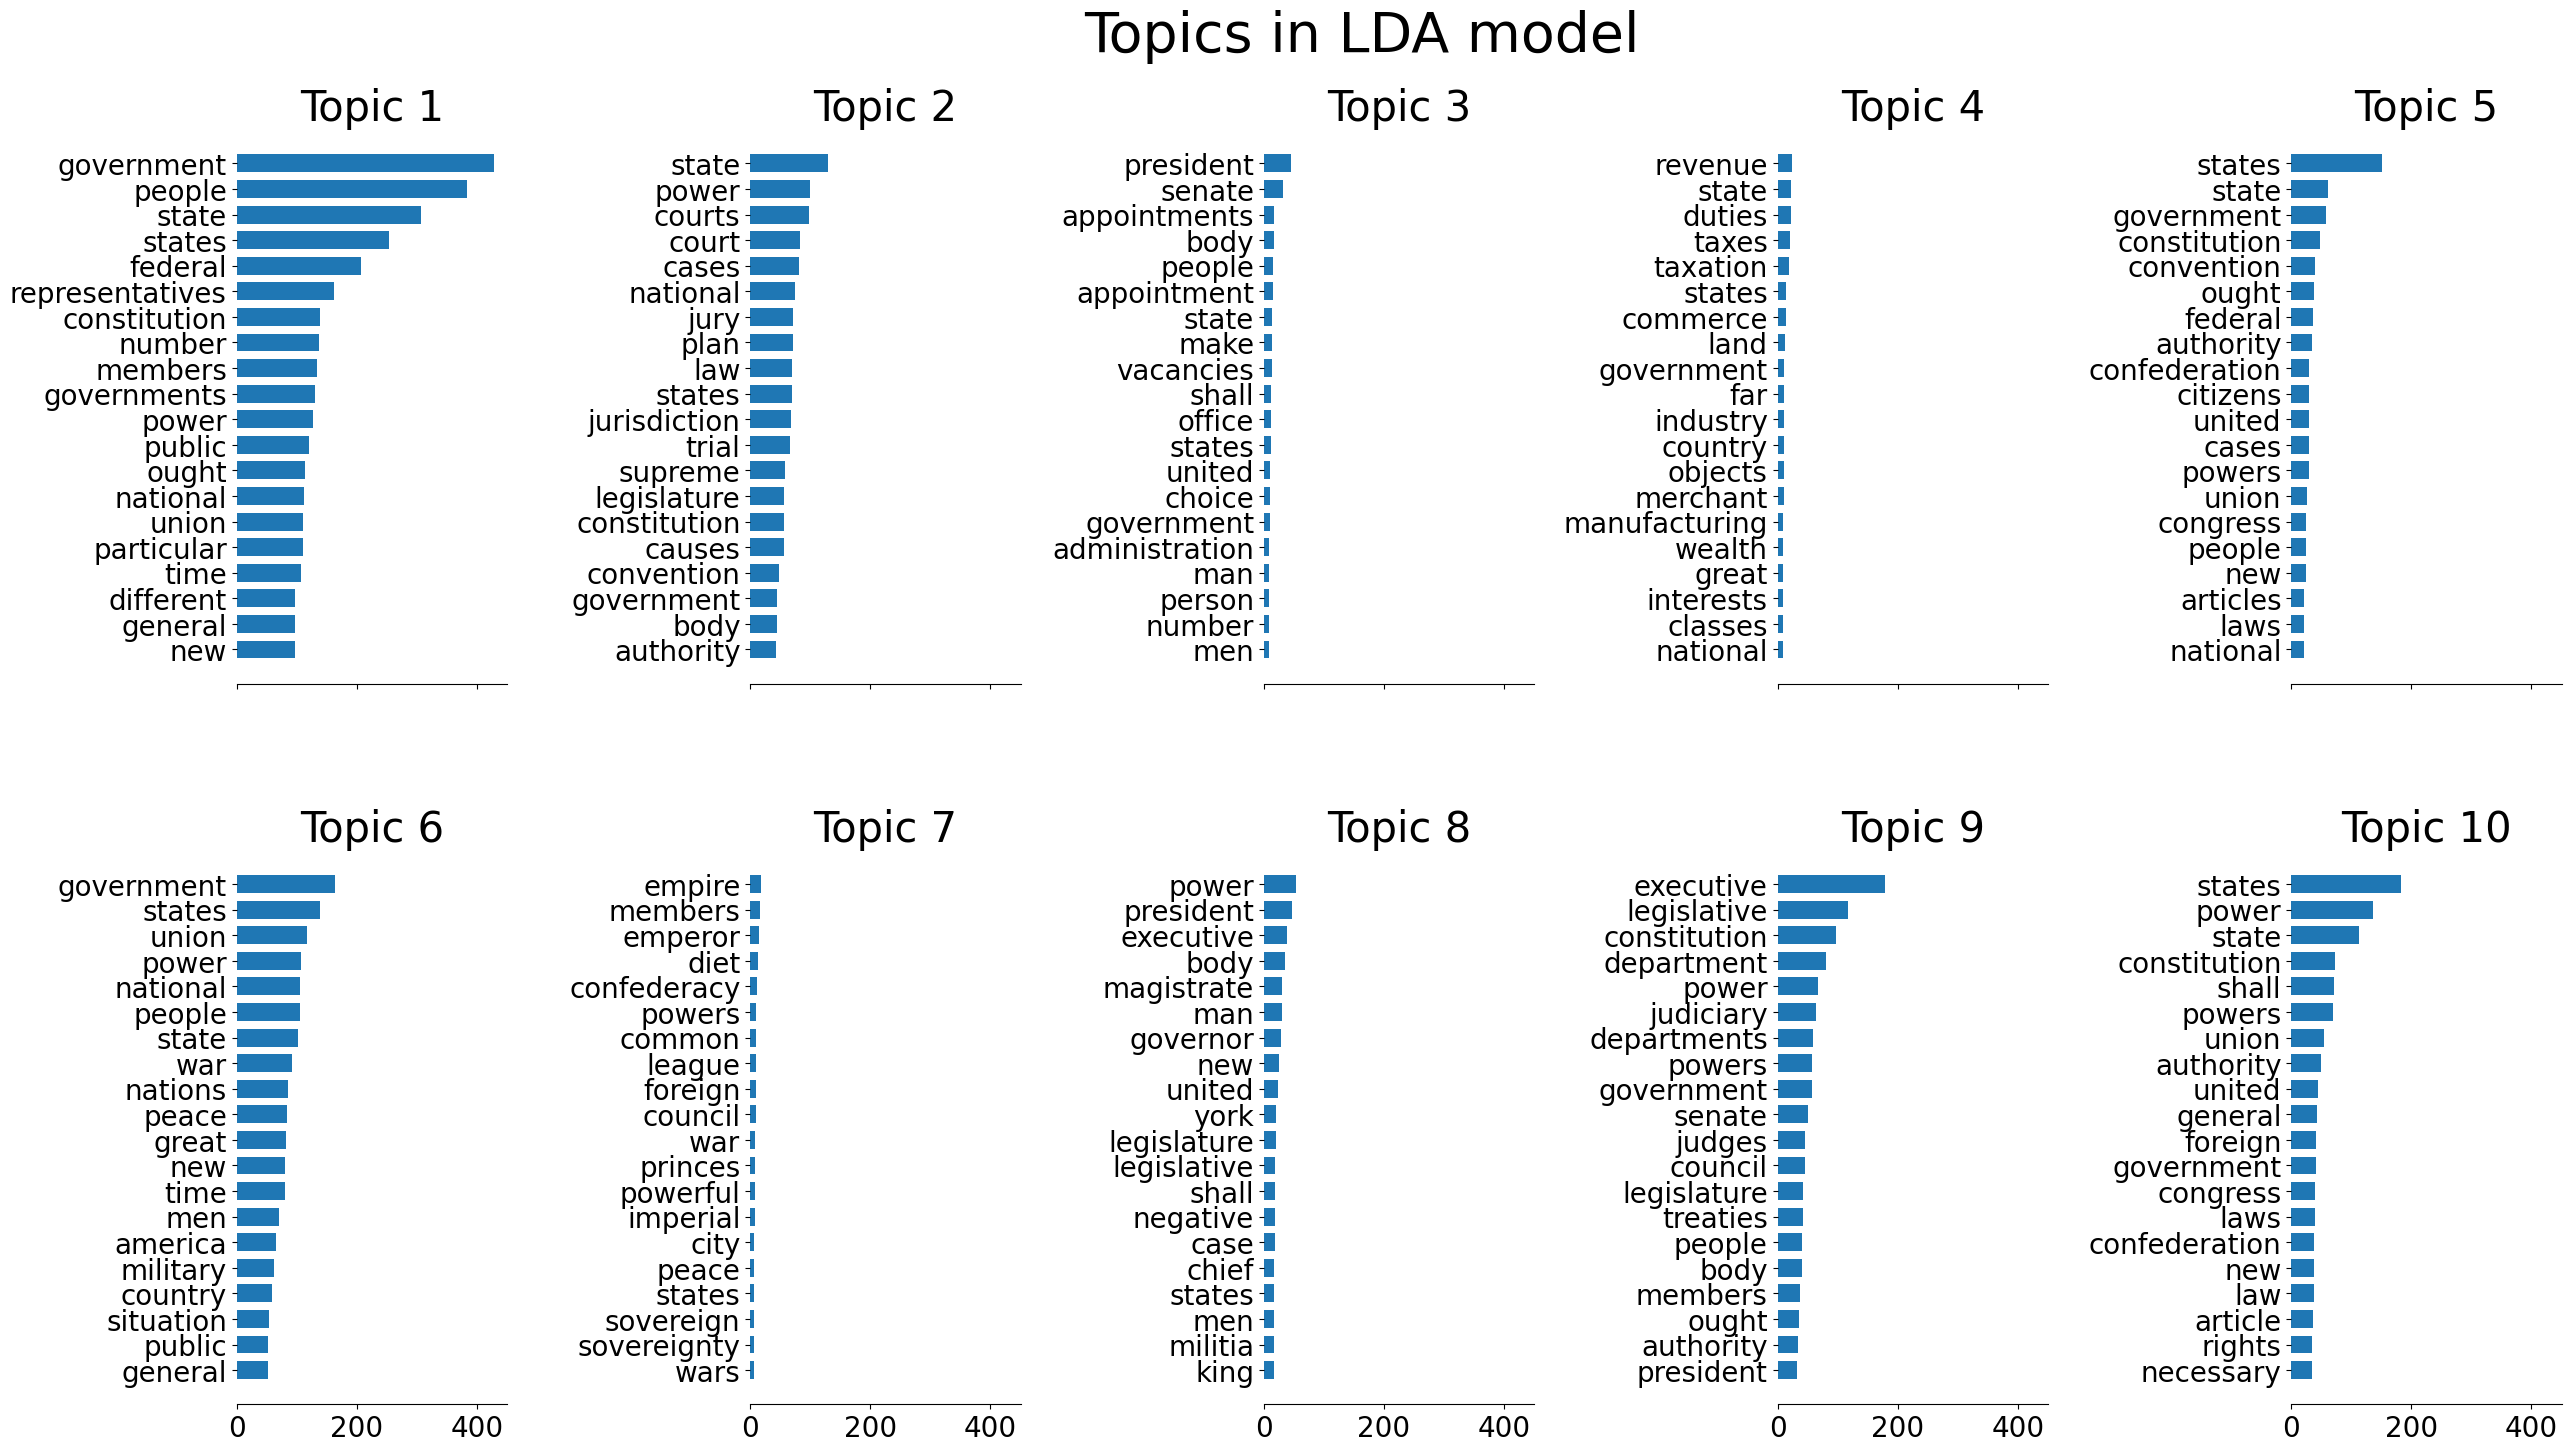

In [ ]:
plot_top_words(lda_components, feature_names_tf, 20, "Topics in LDA model")

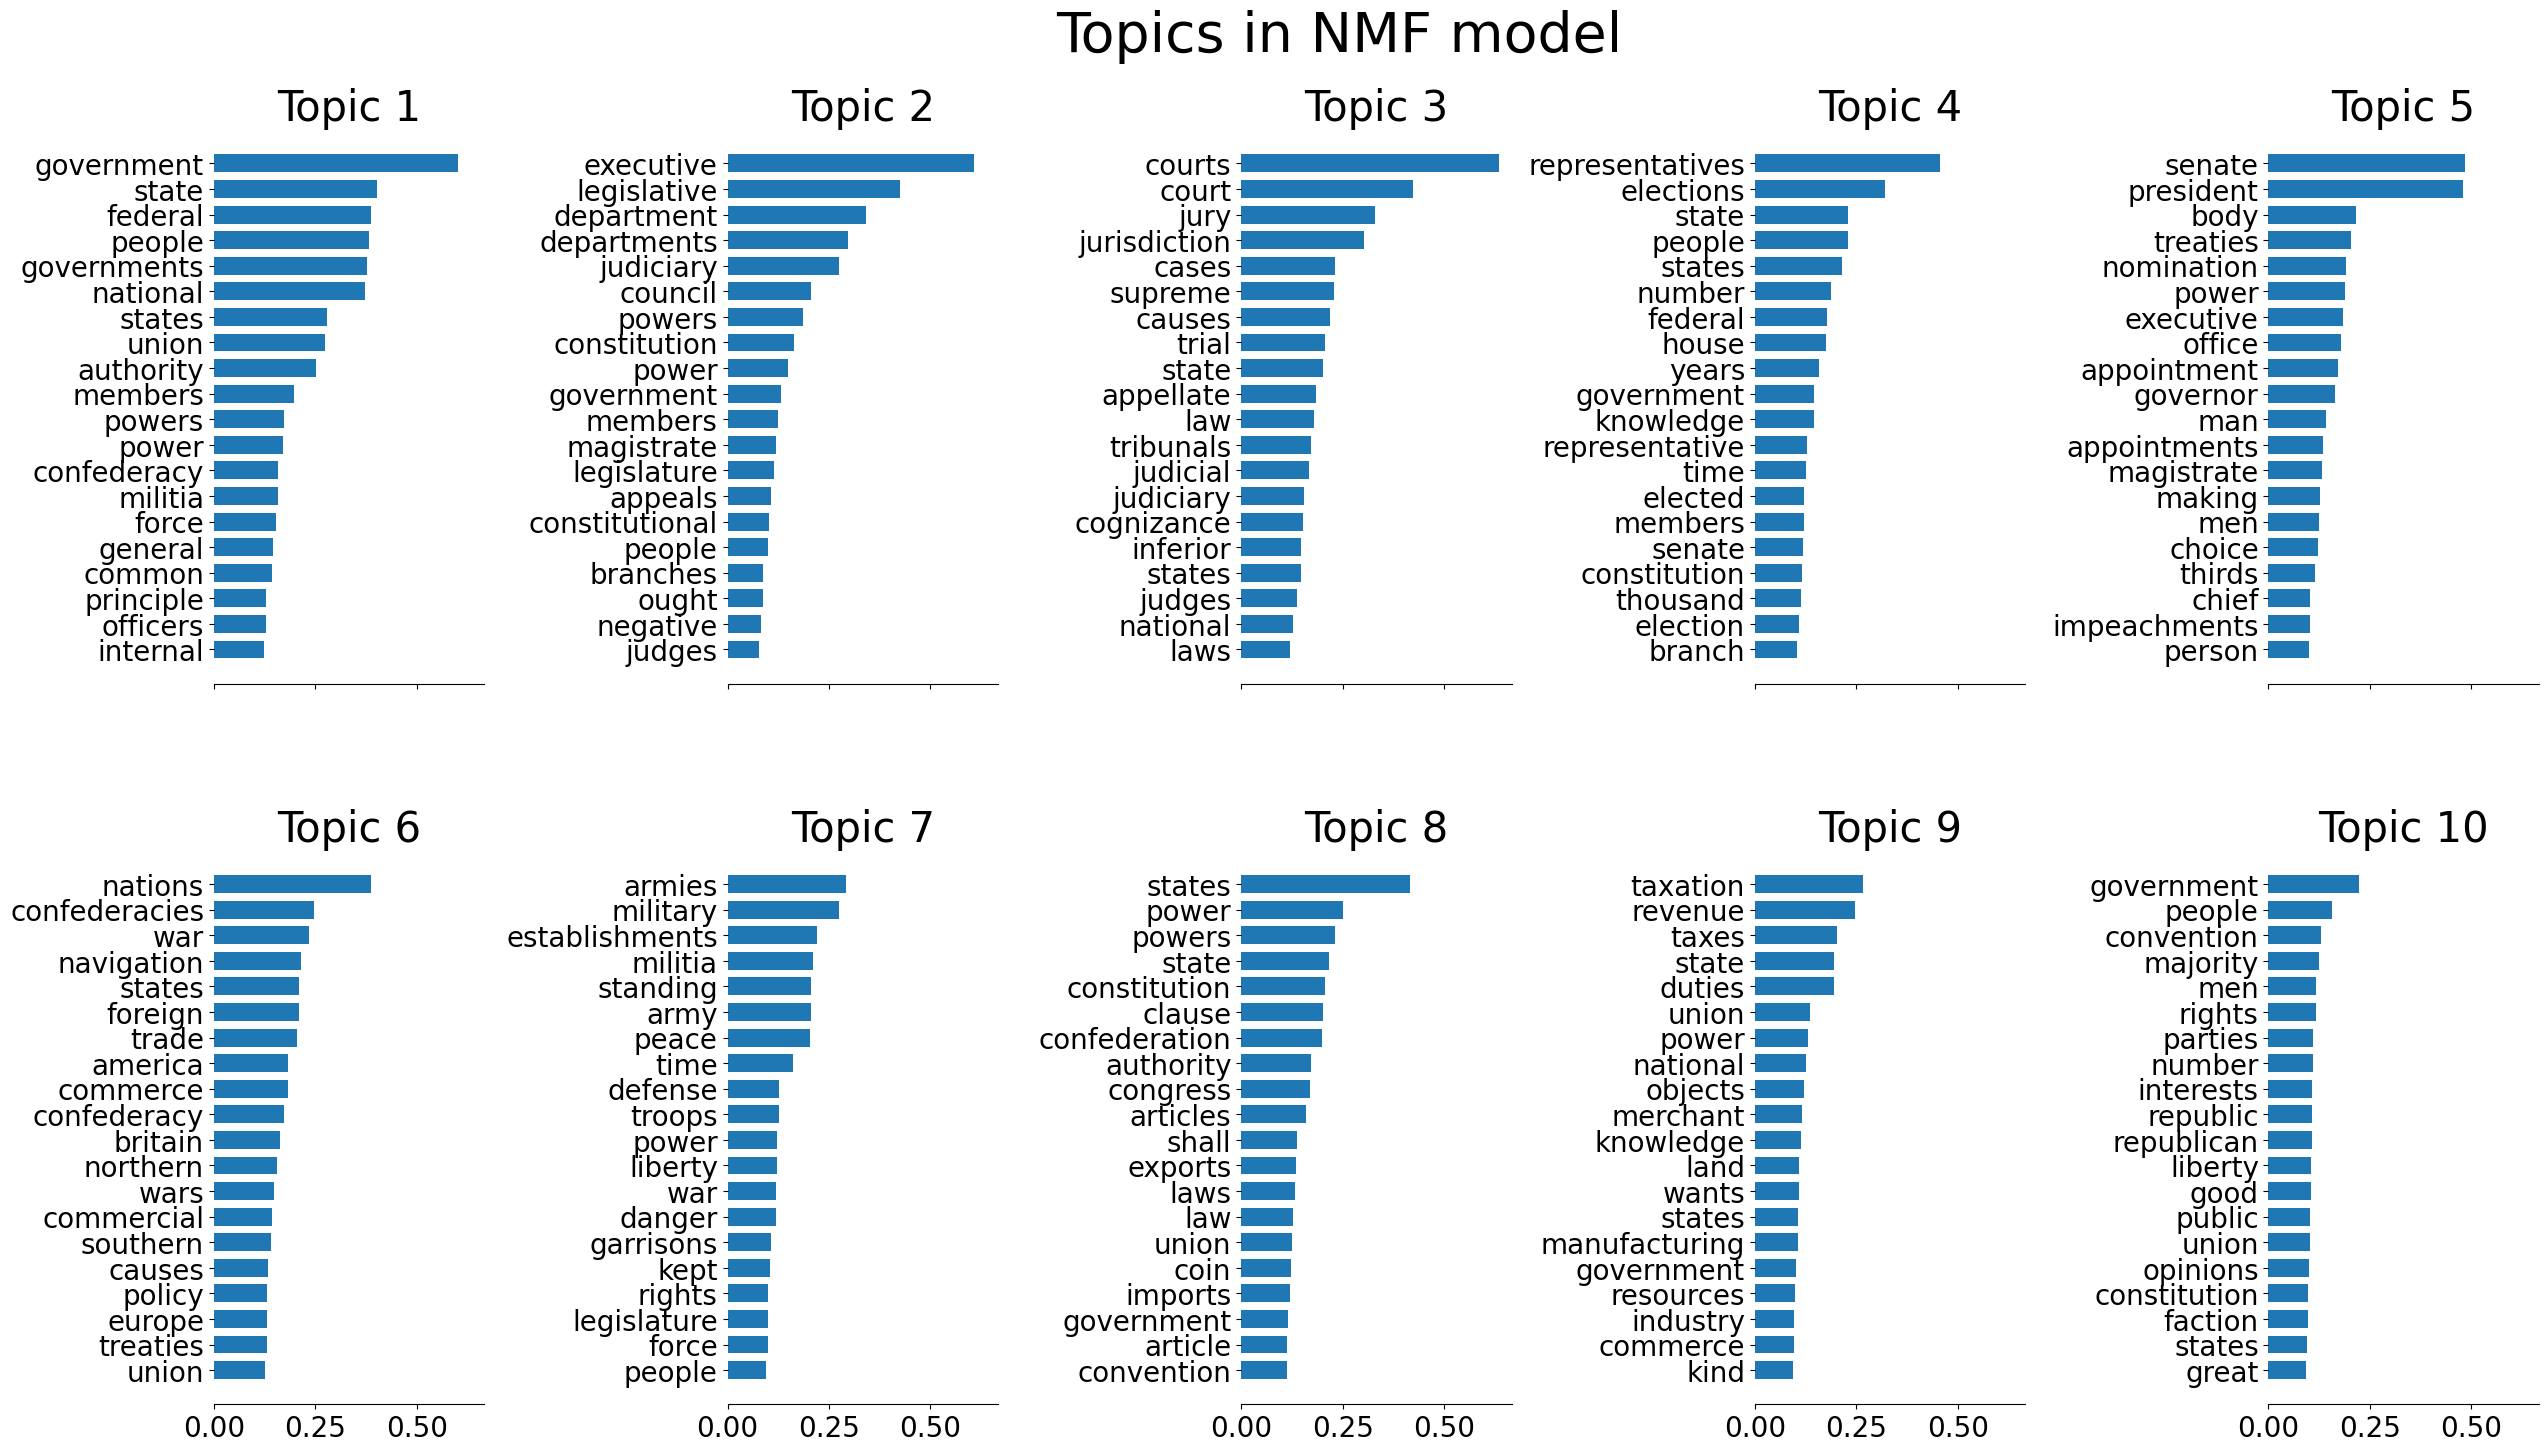

In [ ]:
plot_top_words(H, feature_names_tfidf, 20, "Topics in NMF model")

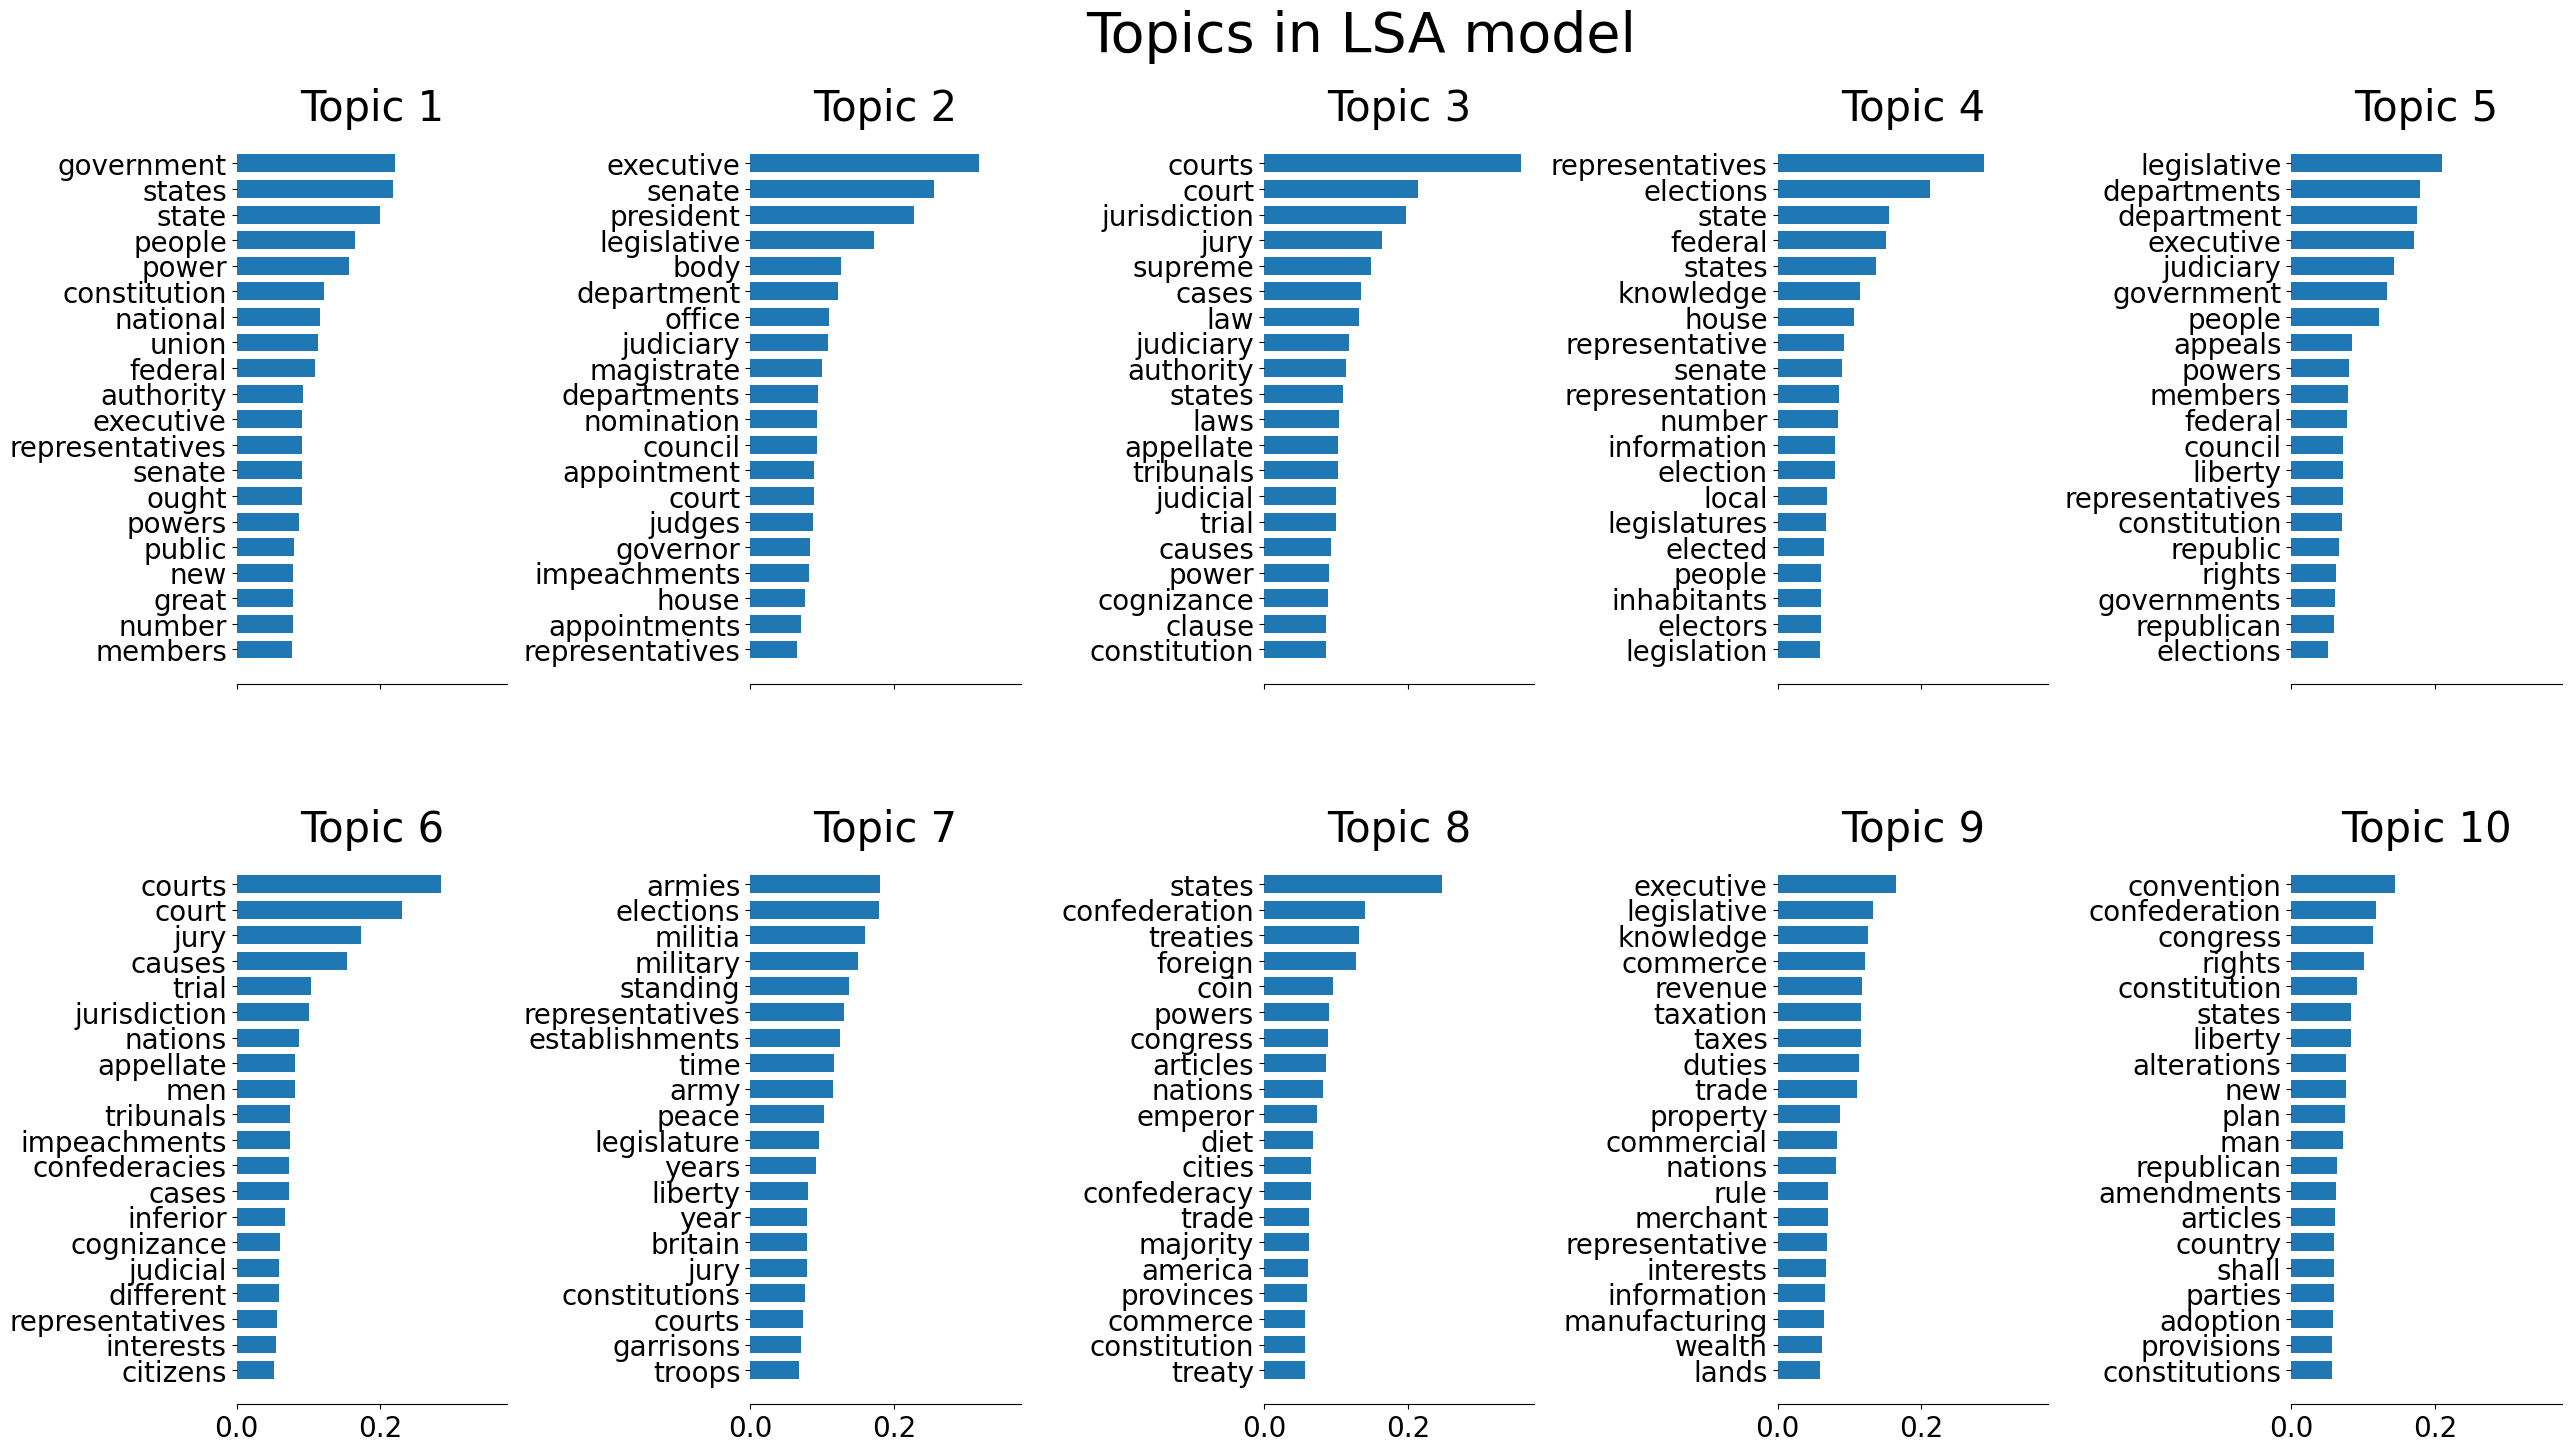

In [ ]:
plot_top_words(svd_comp, feature_names_tfidf, 20, "Topics in LSA model")